# Discovery of Higgs Boson
In this assignment, we'll use data directly from the LHC (Large Hadron Collider) along with Monte-Carlo (MC) simulations to claim the discovery of the Higgs Boson! Please make sure to use the seed 6372 for both PyTorch and Numpy.

<b>Reproducibility note:</b> We make a best effort to keep the neural network training deterministic below. Even with the same seed, small numerical differences across operating systems, hardware, or PyTorch versions can still occur. For the training portions, you do not need to match every printed number exactly. Focus on the qualitative checks instead, for example, decreasing loss and reasonable p-values.

<b> Due Date: 05/01/2026 10:00pm</b> <br>
<b> Submission: Output this file as both .ipynb and .pdf files and zip them before uploading to Gradescope</b> <br>
<b> Total number of points: 52</b> <br>

In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
import util

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader

# Best effort reproducibility
torch.manual_seed(6372)
np.random.seed(6372)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(6372)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass

# Problem Setup

At the LHC, protons are accelerated to incredible speeds before they are collided. The collision results in sub-atomic particles that go through multiple phases of decay. These final decay products are the observables by the LHC detectors. Thus, the Higgs Boson is not observed directly but indirectly through its decay products. Our job is to conclude the existence of the Higgs Boson by observing such decay products. However, things aren't that simple. There are two obstacles to overcome.

First, data generated directly from LHC collisions is huge (on the order of billions of entries). Thus, there has to be some filtering. The first type of filtering is online filtering. This happens automatically by LHC detectors to discard any events/collisions that aren't of primary importance for study, which reduces the size of data by few orders of magnitude. After online filtering, there comes off-line filtering. This filtering happens through the use of sophisticated knowledge of theoretical physics and is typically conducted by humans. <b>The data we have for this assignment comes after these two stages of filtering and is only ~ 500 entries</b>.

Second, even after such filtering, we have confounding decay processes that produce the same final decay products as the Higgs decay! In other words, it is impossible to conclude the Higgs Boson discovery by only looking at the <i>types</i> of decay particles. We then have to look at other properties like kinetic energy, momentum etc... However, such properties are continuous in nature and observing any one value doesn't say much. The only remaining solution, then, is to study the statistical properties of such observations.

So how does statistics help us "discover" the Higgs Boson? Through hypothesis testing!

Luckily, even with confounding processes producing identical types of decay particles, theoretical physics describes different statistical distributions for products coming from Higgs vs. products coming from background. We will denote distribution of data coming Higgs by $Q$ and distribution of data coming from background by $P_0$. To make things more complicated, there is more than one background process. So $P_0$ can only be discribed as a <i>mixture</i> of multiple background processes. In other words, 
$$
P_0 = \sum_i a_i P_{0, i}
$$
where $P_{0, i}$ is the background distribution generated from process $i$, and $a_i$ is the mixing ratio.

Finally, $Q, P_{0, i}$ are not given to us explicitly. In other words, we don't have closed-form expressions for their CDF/PDF. We can only sample from $Q, P_{0, i}$ through Monte-Carlo simulations. We will use these Monte-Carlo samples to compare the real experimental data recorded at the LHC with what the data should be under the null hypothesis. 

<b>1. Data Loading (3 points total)</b>

(1a) (0.5 pt) Read the experimental data from the LHC. Use <b>load_expr_data()</b> function provided in utils.py. Store the dataframe object in the variable <b>data</b>

In [143]:
data = util.load_expr_data()
data

,Unnamed: 0,Run,Event,PID1,Q1,E1,px1,py1,pz1,eta1,...,Q4,E4,px4,py4,pz4,eta4,phi4,mass,mass_z1,mass_z2
0,2,193998,45781635,13,-1,100.9210,37.92880,-1.10326,93.51580,1.633970,...,-1,16.77120,-8.70548,-0.312269,14.331000,1.272670,-3.105740,86.591731,55.103771,6.994068
1,4,194027,65059010,13,-1,100.6390,26.93280,-48.61870,-83.89910,-1.200030,...,-1,10.03260,-6.96710,-4.240460,-5.841220,-0.665870,-2.594840,112.961516,37.790462,24.280513
2,10,194050,1418885795,-13,1,10.4800,9.83429,-1.02873,3.47091,0.344188,...,-1,9.90998,2.89375,2.921130,9.016080,1.526650,0.790107,34.176134,20.909034,8.315275
3,16,194050,327605399,-11,1,62.4877,-24.48300,-41.49830,-39.78930,-0.752696,...,-1,6.94142,6.10657,2.202660,2.457930,0.370119,0.346178,93.102501,49.803585,14.499091
4,17,194050,401484983,11,-1,92.7438,84.72550,-8.66554,36.71380,0.418733,...,-1,93.04140,-1.96028,-20.225300,90.795300,2.202440,-1.667420,232.157083,102.824159,75.204893
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,1953,202973,681363400,-13,1,35.2774,-20.11200,20.53300,-20.45460,-0.662198,...,-1,14.90220,-7.17676,-13.042000,0.681894,0.045791,-2.073860,118.800960,33.348811,18.993248
491,1955,202973,779714361,-13,1,496.6720,90.23110,14.03830,488.20500,2.378180,...,1,56.16620,-47.97900,-23.558700,17.252600,0.317418,-2.685150,567.961424,94.859613,87.828705
492,1963,203002,1426205551,13,-1,38.9458,-1.78869,30.60970,-24.01280,-0.719455,...,1,7.75164,6.80352,3.429050,1.424910,0.185952,0.466851,90.344610,55.497564,9.926399
493,1967,203002,1749862291,13,-1,17.2164,-10.59190,-9.62884,9.56506,0.626430,...,1,11.13120,-5.83405,0.525287,9.464710,1.257320,3.051800,37.630438,9.466776,9.421665


(1b) (0.5 pt) Print the size of the data and column names. 

In [144]:
print(f"data size/shape: {data.shape}")
print(f"column names: {data.columns.tolist()}")

data size/shape: (495, 38)
column names: ['Unnamed: 0', 'Run', 'Event', 'PID1', 'Q1', 'E1', 'px1', 'py1', 'pz1', 'eta1', 'phi1', 'PID2', 'Q2', 'E2', 'px2', 'py2', 'pz2', 'eta2', 'phi2', 'PID3', 'Q3', 'E3', 'px3', 'py3', 'pz3', 'eta3', 'phi3', 'PID4', 'Q4', 'E4', 'px4', 'py4', 'pz4', 'eta4', 'phi4', 'mass', 'mass_z1', 'mass_z2']


(1c) (0.5 pt) Read the simuated MC data. Use the <b>load_processes()</b> function provided in utils.py. Store the list of dataframe objects in a variable <b>mc_processes</b>. Note that the first element of the of the list is the MC Higgs process. The rest are MC background processes.

In [145]:
mc_processes = util.load_processes()
mc_processes

[       Unnamed: 0  Run   Event  PID1  Q1        E1       px1        py1  \
 0               0    1  180905   -13   1   60.1065  -2.35617 -28.739200   
 1               1    1  180917    13  -1   54.9142 -15.37410 -47.631900   
 2               2    1  180932    13  -1   43.8390 -31.67800  22.081200   
 3               3    1  180935   -11   1   75.9368  37.35960  38.597600   
 4               4    1  180957    13  -1  108.3880  37.73410  40.551800   
 ...           ...  ...     ...   ...  ..       ...       ...        ...   
 37388       40525    1  260073   -13   1   37.3863 -23.47210 -26.183600   
 37389       40526    1  260080    13  -1  158.6040 -58.71690  -0.717447   
 37390       40527    1  260084    13  -1  159.0150  38.08260  -6.196040   
 37391       40528    1  260089    13  -1   55.7141  53.88830 -10.463000   
 37392       40529    1  260092   -11   1   66.2822 -57.55820   3.664940   
 
             pz1      eta1  ...       E4       px4        py4       pz4  \
 0      -52

(1d) (0.5 pt) Print the number of MC background processes. Print the size of the Higgs MC process as well as each of the MC background processes. 

In [146]:
print(f"number of MC background processes: {len(mc_processes) - 1}")
print(f"Higgs MC process size/shape: {mc_processes[0].shape}")
for i in range(1, len(mc_processes)):
    print(f"MC background process {i} size/shape: {mc_processes[i].shape}")

number of MC background processes: 6
Higgs MC process size/shape: (37393, 39)
MC background process 1 size/shape: (164425, 39)
MC background process 2 size/shape: (106147, 39)
MC background process 3 size/shape: (85903, 39)
MC background process 4 size/shape: (4, 39)
MC background process 5 size/shape: (8, 39)
MC background process 6 size/shape: (2, 39)


(1e) (0.5 pt) Choose any MC process and print its column names.

In [147]:
print(f"column names: {mc_processes[5].columns.tolist()}")

column names: ['Unnamed: 0', 'Run', 'Event', 'PID1', 'Q1', 'E1', 'px1', 'py1', 'pz1', 'eta1', 'phi1', 'PID2', 'Q2', 'E2', 'px2', 'py2', 'pz2', 'eta2', 'phi2', 'PID3', 'Q3', 'E3', 'px3', 'py3', 'pz3', 'eta3', 'phi3', 'PID4', 'Q4', 'E4', 'px4', 'py4', 'pz4', 'eta4', 'phi4', 'mass', 'mass_z1', 'mass_z2', 'signal']


(1f) (0.5 pt) Compare MC column names with those of the experimental data. There should be one additional column for the MC processes. What is the meaning of this column? Why can't we have such column in the experimental data?

The additional column is "signal", which indicates whether this process is the signal or not (0 for background, 1 for Higgs/signal). This information is not available in the experimental data - we have to find out ourselves through data analysis.

<b>2. Data Munging (2.5 points total)</b>

(2a) (0.5 pt) Below we have defined two lists. <b>object_cols</b> specifies the categorial features of our data. In our case, it describes the <b>PID</b> (Particle ID). <b>irrelevant_cols</b> describes predictors to be discarded.

You task is to one-hot encode the categorial features and discard the irrelevant features. Use <b>encoder, trim</b> from utils.py. Read the documentation carefully. It should be clear enough for you to use them.

In [148]:
object_cols = ['PID1', 'PID2', 'PID3', 'PID4']

# Vanilla
irrelevant_cols = ['Unnamed: 0', 'Run', 'Event', 'Q1', 'Q2', 'Q3', 'Q4', 'mass', 'mass_z1', 'mass_z2']

# your code here

OH_encoder = util.encoder(mc_processes, object_cols)
data, mc_processes = util.trim(OH_encoder, object_cols, irrelevant_cols, mc_processes, data)
data


,E1,px1,py1,pz1,eta1,phi1,E2,px2,py2,pz2,...,6,7,8,9,10,11,12,13,14,15
0,100.9210,37.92880,-1.10326,93.51580,1.633970,-0.029079,38.7062,-17.39130,9.54789,33.23460,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,100.6390,26.93280,-48.61870,-83.89910,-1.200030,-1.064920,24.6255,-12.40350,19.29870,8.95086,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,10.4800,9.83429,-1.02873,3.47091,0.344188,-0.104227,10.1790,9.26634,1.86165,3.77769,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,62.4877,-24.48300,-41.49830,-39.78930,-0.752696,-2.103810,21.5719,1.87631,20.85340,-5.19243,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
4,92.7438,84.72550,-8.66554,36.71380,0.418733,-0.101923,67.6137,-38.05640,46.98800,30.25640,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
490,35.2774,-20.11200,20.53300,-20.45460,-0.662198,2.345840,47.2072,17.62540,-18.93850,39.48660,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
491,496.6720,90.23110,14.03830,488.20500,2.378180,0.154345,154.2420,17.89230,-43.30020,146.95500,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
492,38.9458,-1.78869,30.60970,-24.01280,-0.719455,1.629170,29.9589,19.13590,20.08990,-11.30200,...,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
493,17.2164,-10.59190,-9.62884,9.56506,0.626430,-2.403790,10.9488,-8.92026,-3.15677,-5.50710,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0


<b>Digression on MC Sampling:</b> Recall from the problem setup above that $P_0$ is a mixture of distributions $P_{0, i}$ each with a ratio $a_i$. These ratios describe the relative frequency of each background process in the mixture. Now, MC sampling doesn't only simulate background/higgs collisions. It also simulates the detection process. Because of that, lots of MC generated events won't be detected. Thus, the number of entries for each mc processes dataframe is only a small fraction of the number of MC events generated for that process. For actual numbers of MC events look at <b>nevt_*</b> in util.py. Moreover, the number of MC events for a given process doesn't necessarily match the <i>expected</i> number of events for that process, which is given by <b>luminosity x cross-section</b> (again, look at util.py). Thus, to accurately represent $P_0, Q$, we have to rescale/re-weigh each of the MC processes. 

(2b) (0.5 pt) Create a list <b>weights</b> containing the weights of each of the MC processes. Use <b>compute_weights()</b> in util.py. 

In [149]:
weights = util.compute_weights().tolist()
print(f"weights: {weights}")


weights: [1.546261156436178, 0.0008265557708009798, 0.0019255598703124322, 0.0008265397810542774, 0.019248959734088075, 1.1628603232760466, 0.3605732180038754]


(2c) (0.5 pt) For each of the MC <i>background</i> processes, calculate the sampling frequencies needed to obtain an accurate sample from $P_0$. The sampling frequencies should add up to one. Store these frequencies in a list <b>P0_frequencies</b>. <br>

<b>Hint: </b> Your answer should depend on the sizes of the MC background processes in <b>mc_processes</b>. Also, first element of <b>weights</b> describes the weight of the Higgs process and is irrelevant here.

In [150]:
P0_frequencies = np.array(weights[1:]) / sum(weights[1:])
print(f"P0_frequencies: {P0_frequencies}")

print(f"sum of P0_frequencies: {np.sum(P0_frequencies)}")

P0_frequencies: [5.34551209e-04 1.24530055e-03 5.34540868e-04 1.24487119e-02
 7.52046521e-01 2.33190374e-01]
sum of P0_frequencies: 1.0


(2d) (0.5 pt) Use <b>split</b> in util.py to split the data into three partitions <b>train_processes, sim_processes, synth_processes</b>. <b>train_processes</b> is the training MC data we'll use to learn properties/features about $P_0, Q$ (see below). <b>sim_processes</b> will be used to sample from the background distribution $P_0$ using each of the MC background processes. This will used to perform hypothesis testing. In past years, <b>synth_processes</b> was used for the last phase of the project (which will not be the case this year).

In [151]:
train_processes, sim_processes, synth_processes = util.split(mc_processes)


(2e) (0.5 pt) Add a new column <b>weight</b> for each process in <b>train_processes</b>. Use the <b>weights</b> obtained above which correspond one-by-one to the processes in <b>train_processes</b>. These weights will be used to learn about the properties of $Q, P_0$ later on.

<b>Important checkpoint:</b> If these per-process training weights are incorrect here, the neural network later can look nonsensical even when your training loop is correct.

In [152]:
for i, process in enumerate(train_processes):
    process['weight'] = weights[i]
train_processes


[             E1        px1       py1        pz1      eta1      phi1        E2  \
 8510    19.7861   -1.11170  18.70230    6.36153  0.333341  1.630170  40.57780   
 28395   27.4884    9.69207  23.18620  -11.13830 -0.429858  1.174860  27.16860   
 2118    65.6421  -26.88820 -52.62020   28.58350  0.466596 -2.043190  31.14230   
 144     23.2056    7.56257  10.34250  -19.34760 -1.200330  0.939428   6.48951   
 33623   41.4888   -2.57271 -39.82830   11.33110  0.280226 -1.635300  35.45730   
 ...         ...        ...       ...        ...       ...       ...       ...   
 29584  172.1840 -125.94800  21.74770 -115.37600 -0.810874  2.970610  19.23300   
 1653    59.3136  -40.33400 -36.91380   22.99190  0.409013 -2.400440  56.98410   
 30220   94.5891  -52.78700 -28.06650   73.30010  1.032560 -2.652910  53.52680   
 6703    61.6435   53.05640  28.45180   13.24490  0.218265  0.492229  60.37250   
 33505   21.0303   16.94380   6.64114  -10.53870 -0.550811  0.373549  17.33470   
 
             p

<b>Optional sanity check for parts (2b) to (2e):</b> If you used <code>compute_weights()</code> correctly, the checks below should pass. These training and sampling weights matter a lot later, so it is worth checking them now.

In [190]:
expected_weights = np.array([
    1.54626116e+00,
    8.26555771e-04,
    1.92555987e-03,
    8.26539781e-04,
    1.92489597e-02,
    1.16286032e+00,
    3.60573218e-01,
])

weights_arr = np.asarray(weights)
freq_arr = np.asarray(P0_frequencies)

assert len(weights_arr) == len(mc_processes)
assert np.all(weights_arr > 0)
assert np.isclose(weights_arr[0], weights_arr[1:].sum())
assert np.allclose(weights_arr, expected_weights)

assert len(freq_arr) == len(mc_processes) - 1
assert np.all(freq_arr > 0)
assert np.isclose(np.sum(freq_arr), 1.0)

for weight, process in zip(weights_arr, train_processes):
    assert 'weight' in process.columns
    assert process['weight'].nunique() == 1
    assert np.isclose(process['weight'].iloc[0], weight)

<b>3. Fomulating the problem (1 point total)</b>

Recall that $P_0, Q$ represent the background/Higgs data distributions, respectively. Whatever the ground truth is, the observed experimental data is a mixture of both. More precisely, it has a distribution $\pi Q + (1-\pi) P_0$ for some mixing ratio $\pi \in [0, 1]$. 

(3a) (0.5 pt) If our task is to conclude the discovery of the Higgs Boson through hypothesis testing, describe the null hypothesis in words.

H0: there is no Higgs/signal process in the data

(3b) (0.5 pt) Describe the null/alternative hypotheses mathematically in terms of $\pi$.

H0: pi=0, which makes the Q term disappear so there is no Higgs signal  
H1: pi>0 there exist the Higgs signal that can be discovered

<b>4. Obtaining $\hat{h}$ (12 points total)</b>

Recall from the Neyman-Pearson lemma, the uniformily most powerful test uses the statistic 

$$
h^*(x) = \mathrm{log}\Big(\frac{Q(x)}{P_0(x)}\Big).
$$

Hence, it is natural to study $h^*$. Note, however, that we don't have a closed-form expression for $P_0(x), Q(x)$; only samples. Thus, we'll use the following result:

Any classifier trained with cross-entropy loss
should approximate $h^∗(x)$. More precisely, define the log-loss as usual

$$
l(y, p) = y \mathrm{log} \Big(\frac{1}{p}\Big) + (1-y) \mathrm{log}\Big(\frac{1}{1-p}\Big), \;\;\; y\in \{0, 1\}, p\in [0, 1].
$$

Now, given $n_0 = \nu_0 n$ samples with $y_i = 0$ and $X_i \sim P_0$ and $n_1 = \nu_1 n$
samples with $X_i \sim Q$ we have as $n = n_0 + n_1 \rightarrow \infty$:

$$
\mathrm{log}\Big(\frac{\hat{f}_n}{1-\hat{f}_n}\Big)\rightarrow \mathrm{log}\Big(\frac{\nu_1}{\nu_0}\Big) + h^*
$$

where $\hat{f}_n$ is the sigmoid output of the classifier.
If we have $\nu_0 = \nu_1$, then we have $\mathrm{log}\Big(\frac{\hat{f}_n}{1-\hat{f}_n}\Big)$ is approximately $h^*$.

To that end, our choice of the classifier is a neural network. Moreover, we'll use the <b>weights</b> computed above to re-weigh the training samples for the reasons described in <b>Digression on MC Sampling</b>.

(4a) (0.5 pt) Combine all processes in <b>train_processes</b> into a single dataframe <b>X</b>. Pop the <b>weight</b> column from <b>X</b> and store it in a variable <b>training_weights</b>. Pop the <b>signal</b> column from <b>X</b> into a variable <b>Y</b>.

<b>Important checkpoint:</b> Before moving on to training, make sure <b>training_weights</b> is aligned row-by-row with <b>X</b> and <b>Y</b>, all entries are positive, and the remaining feature columns match the columns in <b>data</b>.

In [154]:
X = pd.concat(train_processes)
training_weights = X.pop('weight')
Y = X.pop('signal')

<b>Optional sanity check for part (4a):</b> This is the last easy place to catch weight alignment issues before training.

In [155]:
training_weights_arr = np.asarray(training_weights)
Y_arr = np.asarray(Y)

assert len(X) == len(Y_arr) == len(training_weights_arr)
assert np.all(training_weights_arr > 0)
assert 'weight' not in X.columns
assert 'signal' not in X.columns
assert set(np.unique(Y_arr)).issubset({0, 1})
assert list(X.columns) == list(data.columns)

(4b) (1 pt) Define a PyTorch <b>Dataset</b> class named <b>MyDataset</b> that indexes the samples <b>X[i], Y[i], training_weights[i]</b>. See https://pytorch.org/tutorials/beginner/basics/data_tutorial.html for tutorial.

In [156]:
class MyDataset(Dataset):
    def __init__(self, X, Y, training_weights):
        # TODO
        self.X = X
        self.Y = Y
        self.training_weights = training_weights

    def __len__(self):
        # TODO
        return len(self.X)

    def __getitem__(self, idx):
        # TODO
        return self.X.iloc[idx].values, self.Y.iloc[idx], self.training_weights.iloc[idx]

dataset = MyDataset(X, Y, training_weights)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

<b>Optional sanity check for part (4b):</b> Run the toy example below before training on the full data.

In [157]:
toy_X = pd.DataFrame({'a': [1.0, 2.0], 'b': [3.0, 4.0]})
toy_Y = pd.Series([0, 1])
toy_w = pd.Series([0.25, 2.0])

toy_dataset = MyDataset(toy_X, toy_Y, toy_w)
toy_x0, toy_y0, toy_w0 = toy_dataset[0]

assert len(toy_dataset) == 2
assert torch.allclose(torch.as_tensor(toy_x0).float(), torch.tensor([1.0, 3.0]))
assert torch.as_tensor(toy_y0).item() == 0
assert np.isclose(torch.as_tensor(toy_w0).item(), 0.25)

(4c) (1 pt) Define a model <b>MyModel</b> that takes as argument the input dimension and returns a Dense Nueral Network (DNN) with three hidden layers. Each hidden layer has 10 units with ReLU activation. The output layer has a single unit with sigmoid activation. See https://pytorch.org/tutorials/beginner/basics/buildmodel_tutorial.html for tutorial.

In [158]:
class MyModel(nn.Module):
    def __init__(self, input_dim):
        super(MyModel, self).__init__()
        # TODO
        self.net = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # TODO
        return self.net(x)

model = MyModel(X.shape[1])
# notice that reduction='none'
criterion = nn.BCELoss(reduction='none')
opt = torch.optim.Adam(model.parameters())

(4d) (2 pts) Construct the model, then fit it to <b>X, Y</b> weighted by <b>training_weights</b> for 10 epochs. See https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html for tutorial. Print the loss for each epoch.

<b>Note: </b> Report the average loss over the full dataset for each epoch. The loss should decrease, and after 10 epochs it should be less than half the loss in the first epoch.

<b>Note: </b> By default, the model you created in (c) has parameters of type <code>torch.float32</code> but <b>x, y, w</b> from your dataloader may have type <code>torch.float64</code>. Convert <b>x, y, w</b> to <code>float32</code> inside the loop.

<b>Reproducibility note:</b> With the seed and deterministic settings above, results should be similar across devices, but small numerical differences are okay. We care about the qualitative behavior here, not an exact match to every printed loss.

In [159]:
for epoch in range(1, 11):
    avg_loss = 0
    model.train()

    for x, y, w in dataloader:
        # TODO
        # Hint: accumulate loss.item() * len(x) if you want avg_loss to represent an epoch average.
        x, y, w = x.float(), y.float().view(-1), w.float().view(-1)

        pred = model(x).squeeze(-1)
        loss = criterion(pred, y)
        weighted_loss = (loss * w).mean()

        # Backpropagation
        weighted_loss.backward()
        opt.step()
        opt.zero_grad()

        avg_loss += weighted_loss.item() * len(x)

    print(f'epoch = {epoch}, loss = {avg_loss / len(dataset):.2e}')

epoch = 1, loss = 8.25e-03
epoch = 2, loss = 5.46e-03
epoch = 3, loss = 4.79e-03
epoch = 4, loss = 3.98e-03
epoch = 5, loss = 3.72e-03
epoch = 6, loss = 3.50e-03
epoch = 7, loss = 3.35e-03
epoch = 8, loss = 3.10e-03
epoch = 9, loss = 3.32e-03
epoch = 10, loss = 3.18e-03


(4e) (2 pts) Plot the histograms of the predicted probabilities of (1) X with label Y=0, (2) X with label Y=1, and (3) <b>data</b> (the experimental data). Show three histograms in the same plot with transparency=0.2. Remember to show the legends as well.

<b>Hint:</b> transparency can be set by using the argument <b>alpha</b> in the plt.hist function.

<b>Hint (added 04/27): </b> Please use `density=True` flag in your histograms as the three items (X with label Y=0, X with label Y=1, <b>data</b>) have very different sample sizes. 

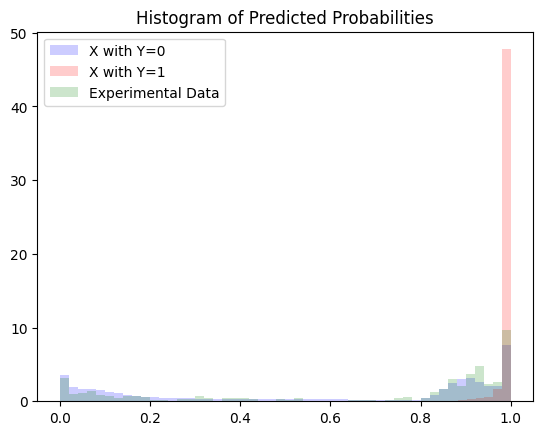

In [160]:
model.eval()

with torch.no_grad():
    x = torch.as_tensor(X.values, dtype=torch.float32)
    probs_X = model(x).squeeze(-1).cpu().numpy()
    d = torch.as_tensor(data.values, dtype=torch.float32)
    probs_data = model(d).squeeze(-1).cpu().numpy()

probs_Y0, probs_Y1 = probs_X[Y == 0], probs_X[Y == 1]

plt.hist(probs_Y0, alpha=0.2, bins=50, density=True, label='X with Y=0', color='blue');
plt.hist(probs_Y1, alpha=0.2, bins=50, density=True, label='X with Y=1', color='red');
plt.hist(probs_data, alpha=0.2, bins=50, density=True, label='Experimental Data', color='green');
plt.legend();
plt.title('Histogram of Predicted Probabilities');

(4f) (0.5 pt) What can you guess about the experimental data from looking at the histograms?

By looking at the histogram, the model mostly assigns higher probabilities to events labeled Y = 1, which is good. Among Y = 0 events, some receive relatively high probabilities - overlap between signal and background are expected

From the discussion above, define

$$
\hat{h} := \mathrm{log}\Big(\frac{\hat{f}_n}{1-\hat{f}_n}\Big)
$$

which will act as an approximation of $h^*$. 

<b>(Added 04/27)</b> Note that this relies on the assumption $\nu_0\simeq \nu_1$, which isn't quite true here. However, even if this assumption is violated, the resulting $\hat{h}$ shifts by a constant for each datapoint $x$, so the results of tests in Part 5 later will still remain valid. 

<b>Evaluating $\hat{h}$</b>

(4g) (1 pt) Argue that $\hat{h}$ can be obtained from the trained DNN above but with replacing the sigmoid activation with a linear activation (i.e. $f(x) = x)$

Because h_hat(x) is already log based and would have produced the same z as we get from the process with the sigmoid. 

(4h) (3 pts) Re-write the <b>MyModel</b> class to remove the sigmoid activation. Then, train it on <b>X, Y</b> weighted by <b>training_weights</b> for 10 epochs.

<b>Reproducibility note:</b> Small numerical differences across devices are okay here as well. Focus on getting stable training and reasonable downstream test results.

In [161]:
class MyModel(nn.Module):
    def __init__(self, input_dim):
        super(MyModel, self).__init__()
        # TODO
        self.net = nn.Sequential(
            nn.Linear(input_dim, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 10),
            nn.ReLU(),
            nn.Linear(10, 1),
        )

    def forward(self, x):
        # TODO
        return self.net(x)

model = MyModel(X.shape[1])
# notice the loss function is different this time
criterion = nn.BCEWithLogitsLoss(reduction='none')
opt = torch.optim.Adam(model.parameters())

In [162]:
for epoch in range(1, 11):
    avg_loss = 0
    for x, y, w in dataloader:
        # TODO
        # Hint: accumulate loss.item() * len(x) if you want avg_loss to represent an epoch average.
        x, y, w = x.float(), y.float().view(-1), w.float().view(-1)

        pred = model(x).squeeze(-1)
        loss = criterion(pred, y)
        weighted_loss = (loss * w).mean()

        # Backpropagation
        weighted_loss.backward()
        opt.step()
        opt.zero_grad()

        avg_loss += weighted_loss.item() * len(x)

    print(f'epoch = {epoch}, loss = {avg_loss / len(dataset):.2e}')

epoch = 1, loss = 1.17e-02
epoch = 2, loss = 5.93e-03
epoch = 3, loss = 5.41e-03
epoch = 4, loss = 5.01e-03
epoch = 5, loss = 4.91e-03
epoch = 6, loss = 4.82e-03
epoch = 7, loss = 4.55e-03
epoch = 8, loss = 4.57e-03
epoch = 9, loss = 4.50e-03
epoch = 10, loss = 4.01e-03


(4i) (0.5 pt) Construct a $P_0$ sample of size $10^5$ using the MC background processes and <b>P0_frequencies</b> computed above. Make sure to pop <b>signal</b> columns at the end. <br>
<b>Note: </b> the first entry in <b>sim_processes</b> concerns Higgs and is irrelevant here.

In [163]:
p0_sample = util.sample(sim_processes[1:], P0_frequencies, 100000)
p0_sample.pop('signal')

158030    0.0
58692     0.0
83212     0.0
16376     0.0
135145    0.0
         ... 
1         0.0
1         0.0
1         0.0
1         0.0
1         0.0
Name: signal, Length: 100000, dtype: float64

(4j) (0.5 pt) Compute $\hat{h}(x)$ for every $x$ in the $P_0$ sample. Store the result in a numpy array <b>h_sim</b>. Compute $\hat{h}(x)$ for every $x$ in experimental data. Store the result in a numpy array <b>h_data</b>.

In [167]:
model.eval()

def h_hat_batch(df):
    t = torch.as_tensor(df.values, dtype=torch.float32)
    with torch.no_grad():
        return model(t).squeeze(-1).cpu().numpy()

h_sim = h_hat_batch(p0_sample)
h_data = h_hat_batch(data)

<b>5. Statistical Tests (14 points total)</b> 

Instead of just looking at the plot, we want to proof the existence of Higgs boson by using hypothesis testing!

<b>Test 1: CLT Test:</b> The CLT test uses the fact that $\hat{h}(X_i)$ are i.i.d where $X_i$ comes from experimental data. We then assume that $n$ is large enough such that we can use the central limit theorem. 

However, how large of an $n$ we need depends on how close the distribution of $\hat{h}(X_i)$ is to a gaussian to start with. The closer to a Gaussian, the smaller the $n$.

(5a) (0.5 pt) Compute and print the mean and standard deviation of $\hat{h}$ on the $P_0$ sample.

In [168]:
print(f"mean of h_sim: {np.mean(h_sim)}")
print(f"std of h_sim: {np.std(h_sim)}")

mean of h_sim: 5.947824478149414
std of h_sim: 1.178437352180481


(5b) (0.5 pt) Because the Gaussian mean and standard deviation are estimated from the same sample, do <b>not</b> use the Kolmogorov-Smirnov test here. Instead, use the <b>Lilliefors test</b> to check whether $\hat{h}(X_i)$ under $P_0$ comes from a Gaussian distribution. Print the p-value.

<b>Hint:</b> You may use <code>from statsmodels.stats.diagnostic import lilliefors</code>.

In [171]:
# Suggested starter:
from statsmodels.stats.diagnostic import lilliefors
_, p_value = lilliefors(h_sim, dist='norm')
print(f'p-value for gaussian fit: {p_value}')

p-value for gaussian fit: 0.0009999999999998899


(5c) (1 pt) Based on the test result, argue against proceeding with the CLT test.

The extremely small p-value suggests that we want to reject the claim that the data follows a normal/gaussian distribution. therefore, the premise of CLT is not fulfilled.

<b>Test 2: Wilcoxon Sum-Rank Test:</b> We'll be using the Mann–Whitney $U$ test (also denoted by the Wilcoxon Sum-Rank test). You can learn more about it here: https://en.wikipedia.org/wiki/Mann%E2%80%93Whitney_U_test. It's a non-parametric test that tries to reject the null hypothesis that the distributions of two populations $X, Y$ are identical for the alternative that one population is stochastically greater than the other. More specifically, given two independent samples $(X_1, \dots, X_n), (Y_1, \dots Y_m)$ it computes the following $U$ statistics
$$
U := \sum_{i=1}^n\sum_{j=1}^m 1_{X_i > Y_j}.
$$
Here, we assume $X_i$ and $Y_j$ are continuous random variables so $\mathbb{P}(X_i = Y_j) = 0, \forall i, j$.
For sample sizes $n, m$ small, exact distribution of $U$ under the null hypothesis is known and tabulated. For large values of $n, m$ a Gaussian approximation is used.

(5d) (1 pt) Argue that we can use a one-sided alternative hypothesis when implementing the Wilcoxon test on $\hat{h}(X_i)$ under experimental data vs. $P_0$. 

because this test's alternative is that one population is stochastically greater than the other, which makes it a one sided test

The Wilcoxon test in scipy.stats.mannwhitneyu used a Gaussian approximation to compute the p-value, which is justified as we have large values of $n, m$. Let's now explore this approximation, and try to implement the test manually ourselves.

(5e) (1 pt) Compute $\mathbb{E}[U]$.

E[U] = nm/2

(5f) (2 pts) Compute $\mathbb{E}[U^2]$<br>
<b>Hint:</b> Expand the square then discuss by cases (squared terms vs cross terms). 

nm/12*(2n^2*m + 2nm^2 - n^2 - m^2 + nm)

(5g) (2 pts) Compute $\mathrm{Var}(U)$.

Var[U] = E[U^2] - (nm/2)^2 = nm(n+m+1)/12

(5h) (1 pt) We cannot directly use the Central Limit Theorem to approximate the distribution of $U$ by Gaussian. Why not?

because U is not made of i.i.d random variables. THey are not completely independent

As you can see, it is not so simple to conclude that the Gaussian approximation is valid. However, if you're interested, you can read https://www.tandfonline.com/doi/abs/10.1080/10691898.2010.11889486. In this paper, the authors recommend the approximation by a Gaussian with the mean/variance you computed above.

(5i) (2 pts) Assuming the Gaussian approximation, write a function <b>wilcoxon_test</b> that takes in the two arrays <b>h1, h2</b> and output the $U$-statistic and the $p$-value. Print the $U$-statistic and the $p$-value.

<b>Hint</b>: going over all pairs accross <b>h_data, h_sim</b> is inefficient. For a more efficient implementation, start by sorting the combined values of <b>h_data, h_sim</b>.

In [172]:
def wilcoxon_test(h1, h2):
    # TODO
    h1 = np.asarray(h1).ravel()
    h2 = np.asarray(h2).ravel()
    n, m = h1.size, h2.size
    ys = np.sort(h2)
    U = int(np.searchsorted(ys, h1, side="left").sum())
    mu = n * m / 2
    var = n * m * (n + m + 1) / 12
    sigma = np.sqrt(var)
    z = (U - mu) / sigma
    # one-sided for "h1 tends to exceed h2":
    pvalue = norm.sf(z)
    return U, float(pvalue)

U, pvalue = wilcoxon_test(h_data, h_sim)
print(f'U = {U}')
print(f'p-value = {pvalue:.2e}')

U = 5620959
p-value = 1.00e+00


<b>Optional sanity check for part (5i):</b> These toy cases let you verify the ranking logic before you run the large arrays.

In [173]:
toy_h1 = np.array([3.0, 4.0])
toy_h2 = np.array([1.0, 2.0])

toy_U, toy_p = wilcoxon_test(toy_h1, toy_h2)
assert toy_U == 4
assert 0 <= toy_p <= 1

toy_U, toy_p = wilcoxon_test(toy_h2, toy_h1)
assert toy_U == 0
assert 0 <= toy_p <= 1

<b>Test 3: Classification Accuracy Test:</b> Previosly, we compare the distributions of <b>h_sim</b> and <b>h_data</b>, which are both logit outputs of the model. 
What if we instead use the class predictions.
Essentially, we compare the ratio of 0's and 1's predictions based on the classifier for both distributions.
Intuitively, it seems to be a worse test than the ones based on logits because we loss some informations when we threshold the outputs into 0's and 1's.

(5j) (0.5 pt) Get the 0-1 predictions of <b>h_sim</b> and <b>h_data</b> by the model by thresholding the logits at 0. Name the arrays as <b>y_sim</b> and <b>y_data</b>, respectively. Then, print the percentage of 1's in each distributions.

In [184]:
h_sim = np.asarray(h_sim).ravel()
h_data = np.asarray(h_data).ravel()
y_sim = (h_sim > 0).astype(np.int64)
y_data = (h_data > 0).astype(np.int64)
print("percentage of 1s in y_sim:  ", 100.0 * y_sim.mean(), "%")
print("percentage of 1s in y_data:", 100.0 * y_data.mean(), "%")

percentage of 1s in y_sim:   98.71799999999999 %
percentage of 1s in y_data: 68.08080808080808 %


(5k) (0.5 pt) What do the percentages of 1's tell you? Does it make sense?

these percentages represent the fraction of h_sim and h_data that cross the decision boundary. 98%>68% shows how often ​(~99%) vs real data (~68%)—so fewer real events land above that cutoff than the synthetic P0 sample

(5l) (2 pts) Now, perform the <b>classification accuracy test</b> by assuming both distributions are binomial that can be approximated as a Gaussian distribution. Write a function <b>accuracy_test</b> which takes in two arrays <b>y1, y2</b> and output the $p$-value. Print the $p$-value.

<b>Hint</b>: similar to pooled two-sampled t-test, but the variance is based on Binomial distribution.

In [185]:
def accuracy_test(y1, y2):
    # TODO
    y1 = np.asarray(y1, dtype=float).ravel()
    y2 = np.asarray(y2, dtype=float).ravel()
    n1, n2 = y1.size, y2.size
    p1, p2 = y1.mean(), y2.mean()
    p_pool = (y1.sum() + y2.sum()) / (n1 + n2)
    # avoid 0 variance when every entry is 0 or every entry is 1 (both samples)
    if p_pool <= 0 or p_pool >= 1:
        return 0.5 if p1 <= p2 else 0.0
    se = np.sqrt(p_pool * (1 - p_pool) * (1 / n1 + 1 / n2))
    z = (p1 - p2) / se
    return float(norm.sf(z))

pvalue = accuracy_test(y_data, y_sim)
print(f'p-value = {pvalue:.2e}')

p-value = 1.00e+00


<b>Optional sanity check for part (5l):</b> In the first toy example there is no difference between the two samples, so the one-sided p-value should be 0.5.

In [187]:
toy_p = accuracy_test(np.array([0, 1, 0, 1]), np.array([0, 1, 0, 1]))
assert np.isclose(toy_p, 0.5)

toy_p = accuracy_test(np.array([1, 1, 1, 1]), np.array([0, 0, 0, 0]))
assert 0 <= toy_p <= 1
assert toy_p < 0.5

<b>6. Enhanced Features (13.5 points total)</b> 

Recall that we discarded a bunch of features as part of the data trimming process. Three of these features were <b>mass, mass_z1, mass_z2</b>. You can think of these features as "smart features" that are engineered/computed through the use of physics knowledge by smart humans to help differentiate Higgs from background. We are now going to explore the effects of using these features in addition to the ones we used previously.

(6a) (4 pts) Re-load the data so that it now contains the smart features <b>mass, mass_z1, mass_z2</b>. Precisely, repeat the following for parts 1 and 2: 

- Read the experimental data from the LHC. Use <b>load_expr_data()</b>. 
- Read the simuated MC data via the <b>load_processes()</b>. 
- (Important) Re-define your <b>irrelevant_cols</b> (make sure to exclude the 3 smart features from the list!!!), then one-hot encode the categorial features and discard the irrelevant features via the <b>encoder, trim</b> functions. 
- Compute the weights of each of the MC processes via <b>compute_weights()</b>. 
- Calculate sampling frequencies. 
- Use <b>split</b> in util.py to split the data into three partitions <b>train_processes, sim_processes, synth_processes</b>. 
- Add a new column <b>weight</b> for each process in <b>train_processes</b>. 
- Re-run your earlier sanity checks for <b>weights</b>, <b>P0_frequencies</b>, and the per-process <b>weight</b> columns before retraining.




In [189]:
object_cols = ['PID1', 'PID2', 'PID3', 'PID4']

# Vanilla
irrelevant_cols = ['Unnamed: 0', 'Run', 'Event', 'Q1', 'Q2', 'Q3', 'Q4']

# your code here

data = util.load_expr_data()
mc_processes = util.load_processes()
OH_encoder = util.encoder(mc_processes, object_cols)
data, mc_processes = util.trim(OH_encoder, object_cols, irrelevant_cols, mc_processes, data)

weights = util.compute_weights().tolist()
P0_frequencies = (np.array(weights[1:]) / np.sum(weights[1:])).tolist()

train_processes, sim_processes, synth_processes = util.split(mc_processes)
for i, process in enumerate(train_processes):
    process["weight"] = weights[i]


(6b) (5 pts) Now we repeat the training process, which involves repeating part 4. The only main difference is that you can use <b>MyModel</b> without sigmoid activation. Precisely, do the following: 

- Create <b>X, training_weights, Y</b> like how you did in 4(a). 
- Create dataset and dataloader objects like how you did in 4(b). Note that you do not need to redefine the classes. 
- Repeat 4(h) by creating a <b>MyModel</b> object, and train them using 10 epochs (again, you do not need to redefine the class). 
- Construct $P_0$ samples of size $10^5$ (and pop <b> signal </b> column in the end). 
- Then create <b>h_sim, h_data</b> objects like how you did in 4(j). 

In [193]:
X = pd.concat(train_processes)
training_weights = X.pop("weight")
Y = X.pop("signal")

dataset = MyDataset(X, Y, training_weights)
dataloader = DataLoader(dataset, batch_size=100, shuffle=True)


model = MyModel(X.shape[1])
# notice the loss function is different this time
criterion = nn.BCEWithLogitsLoss(reduction='none')
opt = torch.optim.Adam(model.parameters())

for epoch in range(1, 11):
    avg_loss = 0
    for x, y, w in dataloader:
        # TODO
        # Hint: accumulate loss.item() * len(x) if you want avg_loss to represent an epoch average.
        x, y, w = x.float(), y.float().view(-1), w.float().view(-1)

        pred = model(x).squeeze(-1)
        loss = criterion(pred, y)
        weighted_loss = (loss * w).mean()

        # Backpropagation
        weighted_loss.backward()
        opt.step()
        opt.zero_grad()

        avg_loss += weighted_loss.item() * len(x)

    print(f'epoch = {epoch}, loss = {avg_loss / len(dataset):.2e}')

P0_sample = util.sample(sim_processes[1:], P0_frequencies, 10**5)
P0_sample.pop("signal")

model.eval()
with torch.no_grad():
    h_sim = model(
        torch.as_tensor(P0_sample.values, dtype=torch.float32, device=torch.device('cpu'))
    ).squeeze(-1).cpu().numpy()
    h_data = model(
        torch.as_tensor(data.values, dtype=torch.float32, device=torch.device('cpu'))
    ).squeeze(-1).cpu().numpy()

epoch = 1, loss = 1.13e-02
epoch = 2, loss = 5.14e-03
epoch = 3, loss = 3.50e-03
epoch = 4, loss = 2.92e-03
epoch = 5, loss = 3.02e-03
epoch = 6, loss = 2.43e-03
epoch = 7, loss = 2.64e-03
epoch = 8, loss = 2.25e-03
epoch = 9, loss = 2.24e-03
epoch = 10, loss = 2.24e-03


(6c) (4 pts) Finally, using your <b>h_sim, h_data</b> objects, calculate the $p$-values of the <b>Wilcoxon</b> test and <b>accuracy test</b>. Print the $p$-values of both tests. 

In [196]:
U_sm, p_wilcox = wilcoxon_test(h_data, h_sim)
print(f"Wilcoxon: p-value = {p_wilcox}")


pvalue = accuracy_test(y_data, y_sim)
print(f"Accuracy-style proportion test p-value = {pvalue}")


Wilcoxon: p-value = 0.9963742195252339
Accuracy-style proportion test p-value = 1.0


(6d) (0.5 pt) Typically, the standard for declaring "new particle" is 5 sigmas. Here, with the help of "smart features," have we achieve such standard?

No. 5 simgma are super extreme; our p values are no where near

However, note that this project is a simplied and scaled-down version of the original experiment. We only have 1 Higgs process and 6 background processes whereas the real-world one has 100 Higgs processes and 1000 background processes. Thus, it is much difficult to achieve 5 sigmas in that case.

<b>7. Discussion (6 points total)</b>

It would be wrong to select what hypothesis test to use <i>after</i> we look at the test results. Ideally, we should be able to choose hypothesis tests before we look at the data given that the assumptions supporting the test hold.

(7a) (1 pt) Ignoring the test performance, what assumptions does the CLT test rely on?

CLT test assumes that the data are i.i.d and that they have finite varaince. Also n needs to be large enough

(7b) (1 pt) Why didn't we proceed using the CLT test?

Lillifors had a strong evidence AGAINST a normal distribution. so therefore we cannot pretend that this is a normal/gaussian distribution to use CLT

(7c) (1 pt) Ignoring the test performance, what assumptions does the Wilcoxon test and the accuracy test rely on?

Wilcoxon assumes independence; accuracy test relies on independence, bernoulli in outcomes.

 (7d) (1 pt) Are you confident in using the Wilcoxon test or the accuracy test?

Should be confident in Wilcoxon here because m is huge. Less confident in accuracy because thresholding at 0 throws away information and is sensitive to calibration.

(7e) (1 pt) Using the results of the test you selected above, did the "smart features" enhance the detection capability? Why do you think so?

not really; we didn't see clear evidences of smart masses improving detection in this pipeline

(7f) (1 pt) Comparing the results of the Wilcoxon test and the accuracy test. What do you notice?

The Wilcoxon and accuracy tests give similar conclusions here: both 
p-values are 1 or close to 1 

In fact, proven in some papers, although thresholding to 0's and 1's, the accuracy test can achieve the same optimal  detection capability compared to other tests that use the logits (or the probabilities).

Congrats on finishing Discovery of Higgs Boson!